# Классификация CC50 > медианы

Необходимо сравнить различные модели с настройкой гиперпараметров для бинарной классификации соединений по уровню их цитотоксичности (CC50 выше или ниже медианы) на основе молекулярных дескрипторов.

Целевая переменная представляет собой бинарный признак, где 1 соответствует соединениям с CC50 выше медианы, которые являются менее токсичным и более безопасным для здоровых клеток, а 0 - соединениям с CC50 ниже или равным медиане.

Такое преобразование позволяет идентифицировать соединения с благоприятным профилем безопасности на ранних этапах скрининга и фокусироваться на потенциально нетоксичных кандидатах для дальнейших исследований.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import VarianceThreshold

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Загрузка данных

In [ ]:
df = pd.read_csv('clean_data.csv')
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


## Подготовка данных к обучению модели

Так как в исходном датасете отсутствует целевая переменная необходимая для данной задачи создадим ее. Затем разделим данные на X, где будут все признаки и y, где будет только что созданная целевая переменная.

Для того чтобы избежать утечки информации в модель, важно исключить из рассмотрения признаки 'СC50, mM' и 'SI'.

In [ ]:
# Формирование целевой переменной
median_cc50 = df['CC50, mM'].median()
df['CC50_high'] = (df['CC50, mM'] > median_cc50).astype(int)

X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'CC50_high'])
y = df['CC50_high']
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,...,0,0,0,0,0,0,0,0,3,0
1,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,...,0,0,0,0,0,0,0,0,3,0
2,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,...,0,0,0,0,0,0,0,0,3,0
3,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,...,0,0,0,0,0,0,0,0,4,0
4,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,...,0,0,0,0,0,0,0,0,0,0


Рассмотрим распределение целевой переменной и проверим сбалансированность классов:

In [ ]:
class_counts = df['CC50_high'].value_counts()
class_counts

,count
CC50_high,
0,485
1,484


Для наглядности визуализируем распределение признака CC50 на грфике и отобразим значение медианы. Дополнительно построим график распределения целевой переменной.

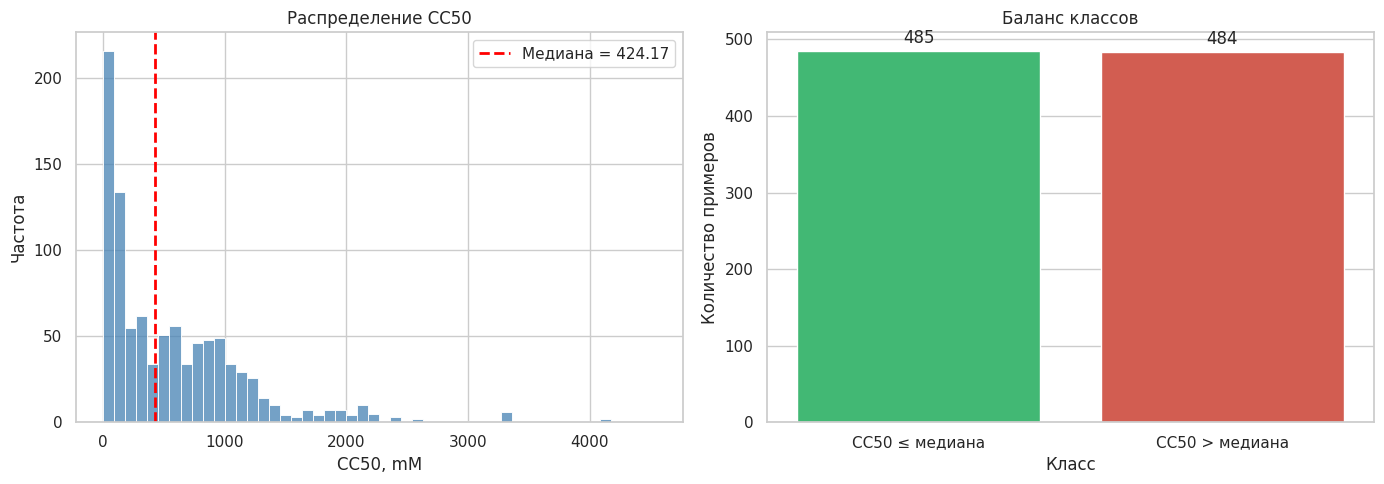

In [ ]:
sns.set(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Распределение IC50 с медианой
sns.histplot(df['CC50, mM'], bins=50, kde=False, color='steelblue', ax=ax1)
ax1.axvline(median_cc50, color='red', linestyle='--', linewidth=2, label=f'Медиана = {median_cc50:.2f}')
ax1.set_title('Распределение CC50')
ax1.set_xlabel('CC50, mM')
ax1.set_ylabel('Частота')
ax1.legend()

class_data = pd.DataFrame({
    'Классы': ['CC50 ≤ медиана', 'CC50 > медиана'],
    'Количество': class_counts.values
})
sns.barplot(data=class_data, x='Классы', y='Количество', hue='Классы',
            palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Баланс классов')
ax2.set_ylabel('Количество примеров')
ax2.set_xlabel('Класс')

# Добавление подписей на столбцы
for i, v in enumerate(class_counts.values):
    ax2.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

На левом графику выше определил медианное значение, равное 424.17 mM. Также по правому графику можно сделать вывод о том, что классы распределены равномерно и дополнительной обработки данных не требуется.

Разделим данные на тренировочную и тестовую выборки в соотношении 80 к 20:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
611,6.002170,6.002170,0.009774,-0.009774,0.528411,41.000000,224.329,208.201,224.098334,82,...,0,0,0,0,0,0,0,0,0,0
572,13.502708,13.502708,0.243384,-2.385574,0.224291,11.608696,330.208,323.152,330.031535,120,...,0,0,0,0,0,0,0,0,0,0
130,15.445767,15.445767,0.200805,-1.452221,0.825443,33.884615,366.429,339.213,366.184252,144,...,0,0,0,0,0,0,0,0,0,0
503,11.301957,11.301957,0.029444,-1.094220,0.728579,10.736842,255.233,246.161,255.064391,94,...,0,0,0,0,0,0,0,0,0,0
945,14.639455,14.639455,0.039258,-1.010647,0.435479,18.047619,576.782,528.398,576.367556,228,...,0,0,0,0,0,0,0,0,0,0


Дополнительно обработаем данные с помощью VarianceThreshold, который позволит нам удалить константные признаки, так как такие признаки не несут никакой полезной информации для предсказания (их дисперсия = 0), но по сравнению с другими задачами в данной задаче негативно влияют на предсказания модели, создавая шум.

In [ ]:
# Удаляем признаки с нулевой дисперсией
selector_var = VarianceThreshold(threshold=0)
X_train = selector_var.fit_transform(X_train)
X_test = selector_var.transform(X_test)

# Получаем оставшиеся признаки
remaining_features = X.columns[selector_var.get_support()]
print(f"Осталось признаков: {len(remaining_features)}")

Осталось признаков: 192


## Обучение моделей

Для данной задачи будем рассматривать 4 различные модели классификации: логистическая регрессия, случайный лес, градиентный бустинг и XGBoost.

Для каждой модели проводится подбор гиперпараметров с помощью GridSearchCV и кросс-валидации, в качестве метрики оптимизации выбрана площадь под ROC-кривой (ROC-AUC).

Оценивать качество моделей будем по трем метрикам:

- точность (Accuracy)

- F1-мера (F1-score)

- площадь под ROC-кривой (ROC-AUC)

Логистическая регрессия предваряется стандартизацией признаков с помощью StandardScaler в составе конвейера. Все модели используют фиксированный random_state=42 для воспроизводимости результатов.



In [ ]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    }

Выше представлена общая функция для предсказания и оценки модели. После подбора гиперпараметров для каждой модели извлекаются лучшие параметры, затем модели оцениваются на тестовой выборке по всем трем метрикам.

**Логистическая регрессия**

In [ ]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

params_log = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_log = GridSearchCV(logreg, params_log, cv=5, scoring='roc_auc')
grid_log.fit(X_train, y_train)

res_log = evaluate(grid_log.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_log.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_log.best_score_:.4f}")

Лучшие параметры: {'model__C': 0.1}
Наилучшая метрика ROC-AUC: 0.8212


**Случайный лес**

In [ ]:
rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, params_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

res_rf = evaluate(grid_rf.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_rf.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Наилучшая метрика ROC-AUC: 0.8246


**Градиентный бустинг**

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

params_gb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, params_gb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)

res_gb = evaluate(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_gb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Наилучшая метрика ROC-AUC: 0.8260


**XGBoost**

In [ ]:
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

params_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb_clf, params_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

res_xgb = evaluate(grid_xgb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_xgb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Наилучшая метрика ROC-AUC: 0.8293


Соберем датафрейм с результатами моделей:

In [ ]:
results = pd.DataFrame({
    'LogReg': res_log,
    'RandomForest': res_rf,
    'GradientBoosting': res_gb,
    'XGBoost': res_xgb
}).T

print(results.sort_values('ROC_AUC', ascending=False))

                  Accuracy        F1   ROC_AUC
GradientBoosting  0.721649  0.727273  0.816346
RandomForest      0.716495  0.720812  0.812148
XGBoost           0.721649  0.732673  0.798757
LogReg            0.711340  0.720000  0.782070


По результатам классификации целевой переменной CC50 > медианы лучшей моделью оказался градиентный бустинг, показавший наибольший ROC-AUC = 0.816 и точность в 0.722. В данной задаче случайный лес уступил по всем метрикам и занял второе место с ROC-AUC = 0.812. XGBoost продемонстрировал самую высокую F1-меру = 0.733 при чуть более низком ROC-AUC, тогда как логистическая регрессия вновь оказалась худшей, что подтверждает нелинейность зависимости между молекулярными дескрипторами и токсичностью CC50.

Интересно отметить, что по сравнению с задачей IC50 > медианы, здесь наблюдается небольшое снижение качества предсказания. Это может указывать на то, что токсичность CC50 является более сложной или зашумленной целевой переменной, чем активность IC50. При этом градиентный бустинг и случайный лес остаются лидерами, а XGBoost показывает менее стабильные результаты.

**Рекомендации:**
В качестве финальной модели для предсказания CC50 > медианы рекомендуется градиентный бустинг как лидер по ROC-AUC и точности. Для улучшения качества можно провести более тщательный подбор гиперпараметров, в частности learning_rate и max_depth, или добавить признаки, связанные с токсикологическими свойствами молекул, например, наличие специфических функциональных групп. Учитывая близость результатов топ-3 моделей, целесообразно применить голосование, с весами, пропорциональными ROC-AUC для повышения устойчивости предсказаний.

